<a href="https://colab.research.google.com/github/ABHIGYA123452/AI-Driven-Student-Performance-Prediction-System/blob/main/Abhigya_IBM_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:


,Attendance,Study_Hours,Assignments,Midterm,Sleep_Hours,Participation,Final_Score
0,68.727006,8.109387,55.702341,77.089210,6.859979,57.554486,70.623145
1,97.535715,19.882731,54.818728,85.767698,8.027162,63.140496,95.761343
2,86.599697,30.807213,94.375275,47.532753,7.800805,89.818318,100.000000
3,79.932924,26.163421,54.972772,73.741187,4.769500,53.800307,91.104876
4,57.800932,28.616518,56.316984,70.022219,4.746247,90.875478,85.018496


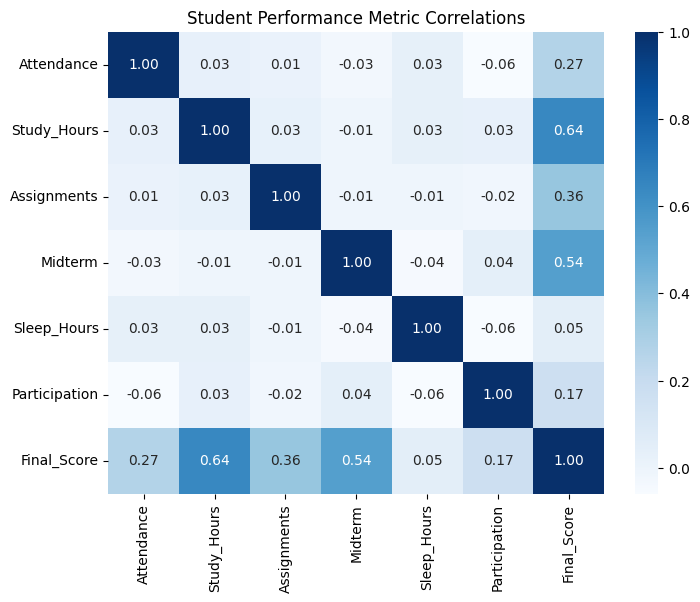

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_samples = 1000

data = {
    'Attendance': np.random.uniform(50, 100, n_samples),
    'Study_Hours': np.random.uniform(2, 35, n_samples),
    'Assignments': np.random.uniform(40, 100, n_samples),
    'Midterm': np.random.uniform(30, 100, n_samples),
    'Sleep_Hours': np.random.uniform(4, 9, n_samples),
    'Participation': np.random.uniform(30, 100, n_samples)
}

df = pd.DataFrame(data)

df['Final_Score'] = (
    (df['Attendance'] * 0.25) +
    (df['Study_Hours'] * 0.8) +
    (df['Assignments'] * 0.25) +
    (df['Midterm'] * 0.35) +
    (df['Participation'] * 0.10) +
    (df['Sleep_Hours'] * 0.5) +
    np.random.normal(0, 3, n_samples)
)
df['Final_Score'] = df['Final_Score'].clip(0, 100)

print("Dataset Preview:")
display(df.head())

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Student Performance Metric Correlations")
plt.show()

Model R² Score: 0.8889
Mean Squared Error (MSE): 15.3110


/tmp/ipykernel_800/786121872.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=X.columns, palette='viridis')


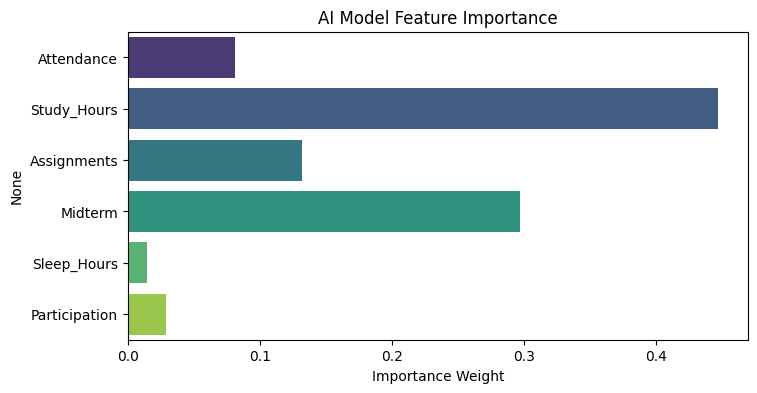

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(columns=['Final_Score'])
y = df['Final_Score']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)
print(f"Model R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")


importances = model.feature_importances_
plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=X.columns, palette='viridis')
plt.title("AI Model Feature Importance")
plt.xlabel("Importance Weight")
plt.show()

In [ ]:
import os
from flask import Flask, request, jsonify, render_template_string

app = Flask(__name__)

HTML_TEMPLATE = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>AI Driven Student Performance Predictor</title>
    <style>
        * { box-sizing: border-box; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; }
        body { background: #f0f2f5; margin: 0; padding: 20px; }
        .container { max-width: 850px; margin: 0 auto; background: white; padding: 30px; border-radius: 12px; box-shadow: 0 4px 15px rgba(0,0,0,0.1); }
        h1 { text-align: center; color: #1a365d; }
        p.desc { text-align: center; color: #666; margin-bottom: 25px; }
        .form-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 15px; }
        .form-group { display: flex; flex-direction: column; }
        label { font-weight: 600; margin-bottom: 5px; color: #333; }
        input { padding: 10px; border: 1px solid #ccc; border-radius: 6px; font-size: 14px; }
        button { grid-column: span 2; padding: 12px; background: #2b6cb0; color: white; border: none; border-radius: 6px; font-size: 16px; font-weight: bold; cursor: pointer; margin-top: 10px; }
        button:hover { background: #1a4971; }
        .results { margin-top: 25px; padding: 20px; background: #f7fafc; border: 1px solid #e2e8f0; border-radius: 8px; display: none; }
        .badge { padding: 5px 12px; border-radius: 20px; color: white; font-weight: bold; display: inline-block; }
        .risk-Low { background: #38a169; }
        .risk-Moderate { background: #dd6b20; }
        .risk-High { background: #e53e3e; }
    </style>
</head>
<body>
    <div class="container">
        <h1>🎓 AI Driven Student Performance Predictor</h1>
        <p class="desc">Enter academic and lifestyle factors to predict final grades & risk profile.</p>

        <form id="predictForm" class="form-grid">
            <div class="form-group"><label>Attendance (%)</label><input type="number" id="attendance" value="85" max="100" min="0"></div>
            <div class="form-group"><label>Study Hours / Week</label><input type="number" id="study_hours" value="15" max="50" min="0"></div>
            <div class="form-group"><label>Assignment Avg (%)</label><input type="number" id="assignments" value="80" max="100" min="0"></div>
            <div class="form-group"><label>Midterm Score (%)</label><input type="number" id="midterm" value="75" max="100" min="0"></div>
            <div class="form-group"><label>Sleep (Hours/Night)</label><input type="number" id="sleep" value="7" max="12" min="0"></div>
            <div class="form-group"><label>Participation Score (%)</label><input type="number" id="participation" value="70" max="100" min="0"></div>
            <button type="button" onclick="makePrediction()">Predict Score</button>
        </form>

        <div class="results" id="resultsCard">
            <h3>Prediction Results</h3>
            <p><strong>Predicted Score:</strong> <span id="scoreVal"></span> / 100</p>
            <p><strong>Grade:</strong> <span id="gradeVal"></span></p>
            <p><strong>Academic Risk:</strong> <span id="riskBadge" class="badge"></span></p>
            <h4>AI Recommendations:</h4>
            <ul id="recsList"></ul>
        </div>
    </div>

    <script>
        async function makePrediction() {
            const payload = {
                Attendance: parseFloat(document.getElementById('attendance').value),
                Study_Hours: parseFloat(document.getElementById('study_hours').value),
                Assignments: parseFloat(document.getElementById('assignments').value),
                Midterm: parseFloat(document.getElementById('midterm').value),
                Sleep_Hours: parseFloat(document.getElementById('sleep').value),
                Participation: parseFloat(document.getElementById('participation').value)
            };

            const response = await fetch('/predict', {
                method: 'POST',
                headers: { 'Content-Type': 'application/json' },
                body: JSON.stringify(payload)
            });

            const data = await response.json();
            document.getElementById('resultsCard').style.display = 'block';
            document.getElementById('scoreVal').innerText = data.score;
            document.getElementById('gradeVal').innerText = data.grade;

            const badge = document.getElementById('riskBadge');
            badge.innerText = data.risk + ' Risk';
            badge.className = 'badge risk-' + data.risk;

            const recList = document.getElementById('recsList');
            recList.innerHTML = '';
            data.recommendations.forEach(r => {
                let li = document.createElement('li');
                li.innerText = r;
                recList.appendChild(li);
            });
        }
    </script>
</body>
</html>
"""

@app.route('/')
def home():
    return render_template_string(HTML_TEMPLATE)

@app.route('/predict', methods=['POST'])
def predict():
    req = request.json
    input_data = np.array([[
        req['Attendance'], req['Study_Hours'], req['Assignments'],
        req['Midterm'], req['Sleep_Hours'], req['Participation']
    ]])

    scaled_input = scaler.transform(input_data)
    pred_score = round(float(model.predict(scaled_input)[0]), 2)

    if pred_score >= 80: grade, risk = 'A', 'Low'
    elif pred_score >= 70: grade, risk = 'B', 'Low'
    elif pred_score >= 55: grade, risk = 'C', 'Moderate'
    else: grade, risk = 'F', 'High'

    recs = []
    if req['Attendance'] < 75: recs.append("Attendance is low (<75%). Attend more lectures.")
    if req['Study_Hours'] < 12: recs.append("Increase study time to at least 12 hours/week.")
    if req['Midterm'] < 60: recs.append("Schedule extra tutoring for exam preparation.")
    if not recs: recs.append("Student is performing optimally!")

    return jsonify({'score': pred_score, 'grade': grade, 'risk': risk, 'recommendations': recs})

In [ ]:
from google.colab.output import eval_js
print("Starting web server...")

colab_url = eval_js("google.colab.kernel.proxyPort(5000)")
print(f"👉 LIVE WEBSITE URL: {colab_url}")

if __name__ == '__main__':
    app.run(port=5000)

Starting web server...
👉 LIVE WEBSITE URL: https://5000-m-s-kkb-use1b0-3k0rbb4gmucwp-b.us-east1-0.prod.colab.dev
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [17/Aug/2026 14:17:33] "GET / HTTP/1.1" 200 -
